In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive

 AD_LAB_PROJECT		      My_Resume.pdf
 Bash.pdf		     'problem_solving_basic certificate.pdf'
'Colab Notebooks'	     'python_basic certificate.pdf'
 Data_Science_and_ML.pdf      python.pdf
 emotion_project	      Research_Paper.gdoc
'Hacker Rank.png'	      Resume
'java certificate.pdf'	     'Resume Final.pdf'
'Mission Insights. pdf.pdf'   Resume_Without_Course.pdf


In [4]:
#import os
# os.makedirs('/content/drive/MyDrive/emotion_project', exist_ok=True)

In [5]:
## !ls /content/drive/MyDrive

In [6]:
# ##import os

# base = "/content/drive/MyDrive/emotion_project"

# folders = [
#     "data/raw",
#     "data/processed",
#     "notebooks",
#     "models",
#     "results",
#     "reports",
#     "scripts"
# ]

# for folder in folders:
#     os.makedirs(os.path.join(base, folder), exist_ok=True)

# print("Project folders created successfully!")

In [8]:
import pandas as pd

path = "/content/drive/MyDrive/emotion_project/data/raw/Twitter_Emotions.parquet"

df = pd.read_parquet(path)

df.head(100)


,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2
...,...,...
95,i really liked it and i have a feeling the bel...,1
96,i feel like talking in a snobbish uppity accen...,3
97,i don t feel as needy and desperate to prove t...,0
98,i feel bad for my mum who carries everything a...,0


In [ ]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [ ]:
df['label'].unique()

array([0, 1, 2, 3, 4, 5])

In [ ]:
df['label'].value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


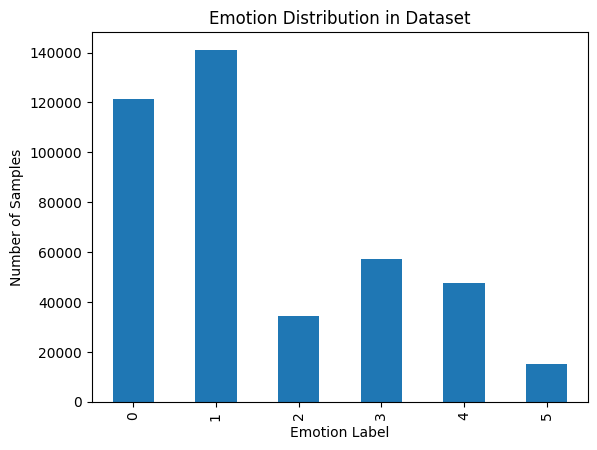

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().sort_index().plot(kind='bar')

plt.title("Emotion Distribution in Dataset")
plt.xlabel("Emotion Label")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
emotion_map = {
0: "sadness",
1: "joy",
2: "love",
3: "anger",
4: "fear",
5: "surprise"
}

df["emotion"] = df["label"].map(emotion_map)

In [ ]:
df.head(5)

,text,label,emotion
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love


Emotion Distribution Graph

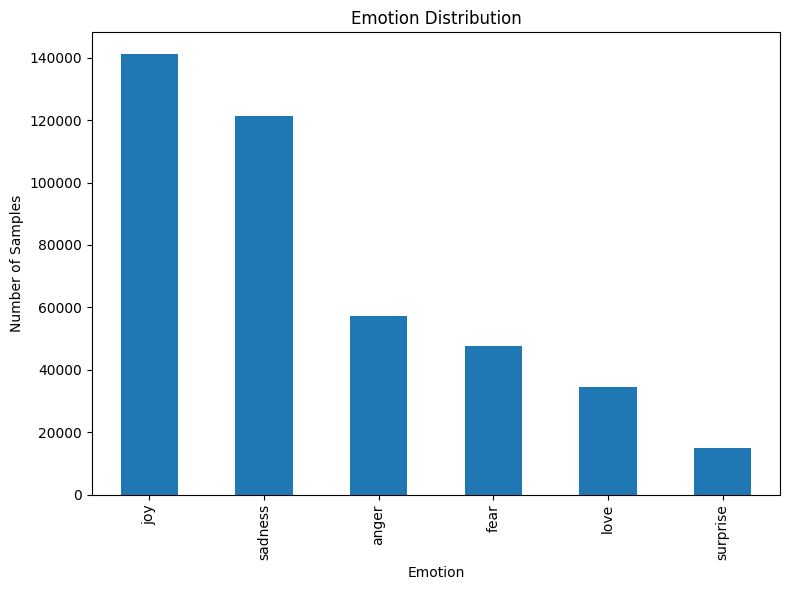

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df['emotion'].value_counts().plot(kind='bar')

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/emotion_project/results/emotion_graph.png")

plt.show()

Text Cleaning

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)   # remove URLs

    text = re.sub(r"@\w+", "", text)      # remove mentions

    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special characters

    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces

    return text

In [ ]:
df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
df[["text","clean_text"]].head(1000)

,text,clean_text
0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...
1,im alone i feel awful,im alone i feel awful
2,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...
3,i was feeling a little low few days back,i was feeling a little low few days back
4,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...
...,...,...
995,i am doing now is not gods will so i will not ...,i am doing now is not gods will so i will not ...
996,i am not feeling all that creative today,i am not feeling all that creative today
997,i was feeling increasingly confident that not ...,i was feeling increasingly confident that not ...
998,i feel like my mind is so blank,i feel like my mind is so blank


Analyzing the tweet length

In [ ]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))


In [ ]:
df["text_length"].describe()

,text_length
count,416809.000000
mean,19.210658
std,11.051022
min,1.000000
25%,11.000000
50%,17.000000
75%,25.000000
max,178.000000


Tokenizer Create(Breaking data into smaller manageble unit.)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(df["clean_text"])

In [ ]:
import pickle

with open("/content/drive/MyDrive/emotion_project/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully")

Tokenizer saved successfully


In [ ]:
sequences = tokenizer.texts_to_sequences(df["clean_text"])

X = pad_sequences(sequences, maxlen=MAX_LEN)

In [ ]:
y = df["label"]

In [ ]:
X.shape

(416809, 50)

Train / Test Split

Training data -> model learn karega



Testing data -> model performance check karega

Hum isse 0.8:0.2 me todenge

80% training
20% testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (333447, 50)
Testing samples: (83362, 50)


# BiLSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(input_dim=20000, output_dim=128, input_length=50))

model.add(Bidirectional(LSTM(64)))

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dense(6, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/3
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 507s 214ms/step - accuracy: 0.7682 - loss: 0.6039 - val_accuracy: 0.9337 - val_loss: 0.1143
Epoch 2/3
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 501s 214ms/step - accuracy: 0.9372 - loss: 0.1126 - val_accuracy: 0.9353 - val_loss: 0.1047
Epoch 3/3
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 502s 214ms/step - accuracy: 0.9407 - loss: 0.0999 - val_accuracy: 0.9359 - val_loss: 0.1050


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 50s 19ms/step - accuracy: 0.9364 - loss: 0.1031
Test Loss: 0.10411693900823593
Test Accuracy: 0.9359660148620605


In [ ]:
import numpy as np

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 48s 18ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     24504
           1       0.93      0.98      0.96     28247
           2       0.99      0.70      0.82      6853
           3       0.94      0.93      0.93     11339
           4       0.88      0.91      0.90      9376
           5       0.87      0.73      0.79      3043

    accuracy                           0.94     83362
   macro avg       0.93      0.87      0.90     83362
weighted avg       0.94      0.94      0.93     83362



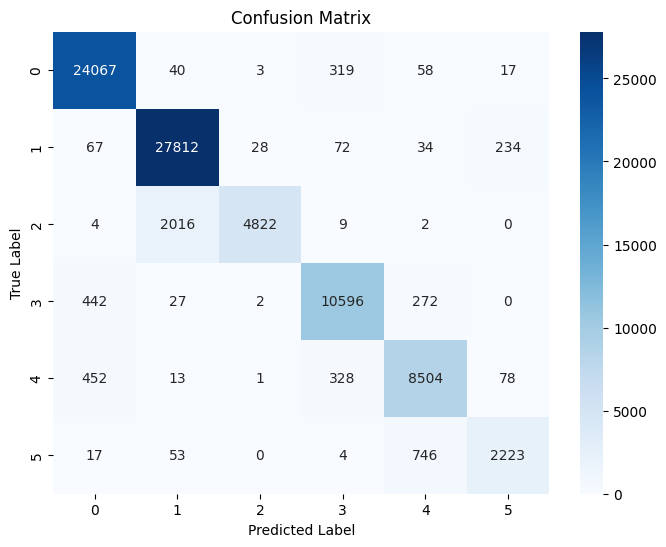

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("/content/drive/MyDrive/emotion_project/results/bilstm_confusion_matrix.png")


plt.show()

In [ ]:
model.save("/content/drive/MyDrive/emotion_project/models/bilstm_baseline_model.keras")

# Saving Data For Using in Attention Model

In [ ]:
import numpy as np

np.save("/content/drive/MyDrive/emotion_project/data/processed/X_train.npy", X_train)
np.save("/content/drive/MyDrive/emotion_project/data/processed/X_test.npy", X_test)
np.save("/content/drive/MyDrive/emotion_project/data/processed/y_train.npy", y_train)
np.save("/content/drive/MyDrive/emotion_project/data/processed/y_test.npy", y_test)

# Accuracy Graph

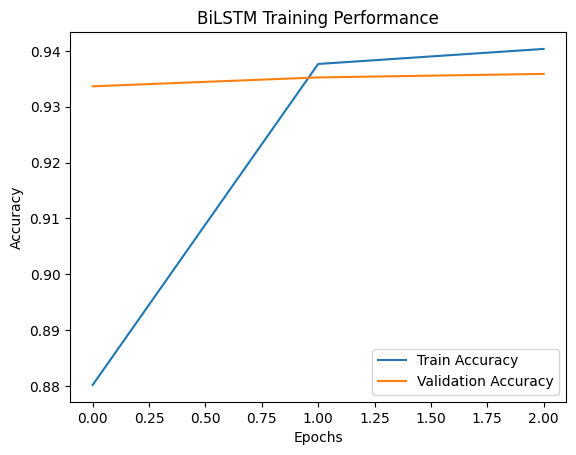

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("BiLSTM Training Performance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("/content/drive/MyDrive/emotion_project/results/bilstm_training_accuracy.png")

plt.show()

# Loss Graph

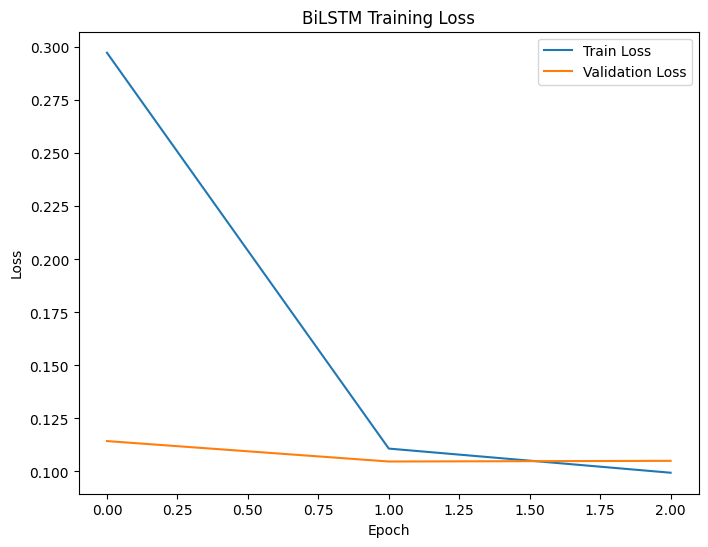

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("BiLSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("/content/drive/MyDrive/emotion_project/results/bilstm_loss_curve.png")

plt.show()

In [ ]:
report = classification_report(y_test, y_pred)

with open("/content/drive/MyDrive/emotion_project/results/bilstm_classification_report.txt", "w") as f:
    f.write(report)